In [140]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [141]:
df = pd.read_csv('House Price Prediction Dataset.csv')

In [142]:
df

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056
...,...,...,...,...,...,...,...,...,...,...
1995,1996,4994,5,4,3,1923,Suburban,Poor,No,295620
1996,1997,3046,5,2,1,2019,Suburban,Poor,Yes,580929
1997,1998,1062,5,1,2,1903,Rural,Poor,No,476925
1998,1999,4062,3,1,2,1936,Urban,Excellent,Yes,161119


In [143]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Id         2000 non-null   int64
 1   Area       2000 non-null   int64
 2   Bedrooms   2000 non-null   int64
 3   Bathrooms  2000 non-null   int64
 4   Floors     2000 non-null   int64
 5   YearBuilt  2000 non-null   int64
 6   Location   2000 non-null   str  
 7   Condition  2000 non-null   str  
 8   Garage     2000 non-null   str  
 9   Price      2000 non-null   int64
dtypes: int64(7), str(3)
memory usage: 156.4 KB


In [144]:
df.shape

(2000, 10)

In [146]:
df.corr(numeric_only=True)

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
Id,1.000000,-0.012966,-0.016393,-0.025433,-0.002025,0.008840,-0.025643
Area,-0.012966,1.000000,0.047523,0.021881,0.017749,-0.011609,0.001542
Bedrooms,-0.016393,0.047523,1.000000,-0.011990,0.010435,-0.014125,-0.003471
Bathrooms,-0.025433,0.021881,-0.011990,1.000000,0.029089,-0.000839,-0.015737
Floors,-0.002025,0.017749,0.010435,0.029089,1.000000,-0.006474,0.055890
YearBuilt,0.008840,-0.011609,-0.014125,-0.000839,-0.006474,1.000000,0.004845
Price,-0.025643,0.001542,-0.003471,-0.015737,0.055890,0.004845,1.000000


In [154]:
df.isnull().sum()

Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64

In [157]:
df.corr(numeric_only=True)

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
Id,1.000000,-0.012966,-0.016393,-0.025433,-0.002025,0.008840,-0.025643
Area,-0.012966,1.000000,0.047523,0.021881,0.017749,-0.011609,0.001542
Bedrooms,-0.016393,0.047523,1.000000,-0.011990,0.010435,-0.014125,-0.003471
Bathrooms,-0.025433,0.021881,-0.011990,1.000000,0.029089,-0.000839,-0.015737
Floors,-0.002025,0.017749,0.010435,0.029089,1.000000,-0.006474,0.055890
YearBuilt,0.008840,-0.011609,-0.014125,-0.000839,-0.006474,1.000000,0.004845
Price,-0.025643,0.001542,-0.003471,-0.015737,0.055890,0.004845,1.000000


In [158]:
from pandas.api.types import (
    is_string_dtype,
    is_float_dtype,
    is_integer_dtype
)

categorical_columns = []
numerical_columns = []

for col in df.columns:

    if is_string_dtype(df[col]):
        categorical_columns.append(col)

    elif is_float_dtype(df[col]) or is_integer_dtype(df[col]):
        numerical_columns.append(col)

In [159]:
numerical_columns

['Id', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'Price']

In [160]:
categorical_columns

['Location', 'Condition', 'Garage']

In [161]:
for col in categorical_columns:

    print(f"\n================ {col} ================")
    print(df[col].value_counts())


================ Location ================
Location
Downtown    558
Urban       485
Suburban    483
Rural       474
Name: count, dtype: int64

================ Condition ================
Condition
Fair         521
Excellent    511
Poor         507
Good         461
Name: count, dtype: int64

================ Garage ================
Garage
No     1038
Yes     962
Name: count, dtype: int64


In [162]:
correlation = df.corr(numeric_only=True)

print("\nCorrelation Matrix")
print(correlation)


Correlation Matrix
                 Id      Area  Bedrooms  Bathrooms    Floors  YearBuilt  \
Id         1.000000 -0.012966 -0.016393  -0.025433 -0.002025   0.008840   
Area      -0.012966  1.000000  0.047523   0.021881  0.017749  -0.011609   
Bedrooms  -0.016393  0.047523  1.000000  -0.011990  0.010435  -0.014125   
Bathrooms -0.025433  0.021881 -0.011990   1.000000  0.029089  -0.000839   
Floors    -0.002025  0.017749  0.010435   0.029089  1.000000  -0.006474   
YearBuilt  0.008840 -0.011609 -0.014125  -0.000839 -0.006474   1.000000   
Price     -0.025643  0.001542 -0.003471  -0.015737  0.055890   0.004845   

              Price  
Id        -0.025643  
Area       0.001542  
Bedrooms  -0.003471  
Bathrooms -0.015737  
Floors     0.055890  
YearBuilt  0.004845  
Price      1.000000  


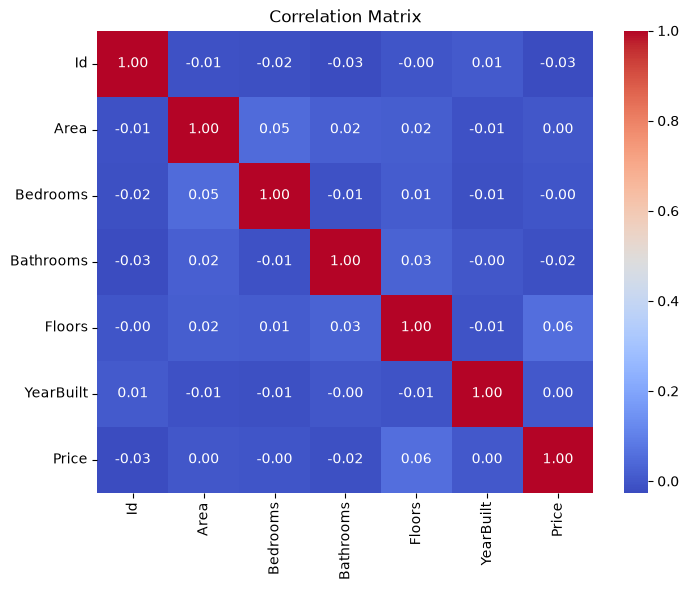

In [165]:
plt.figure(figsize=(8,6))
sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

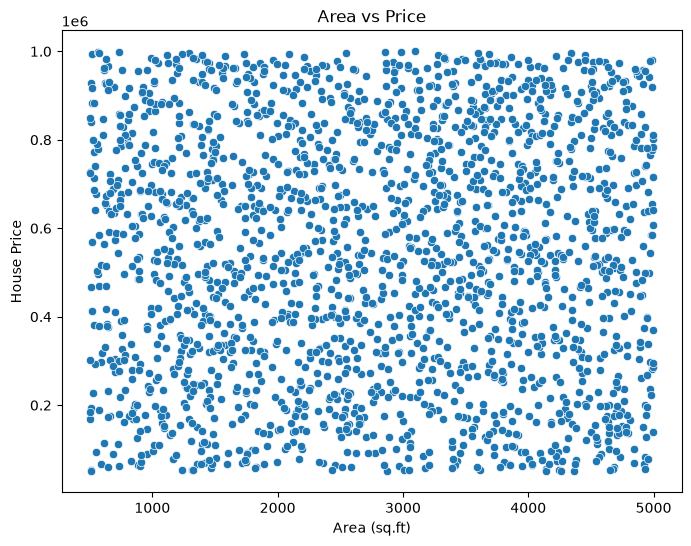

In [166]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Area",
    y="Price"
)

plt.title("Area vs Price")
plt.xlabel("Area (sq.ft)")
plt.ylabel("House Price")

plt.show()

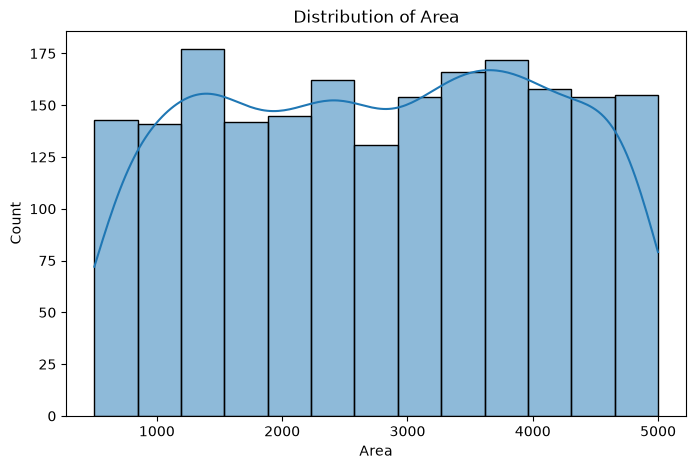

In [167]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Area"],
    kde=True
)

plt.title("Distribution of Area")
plt.show()

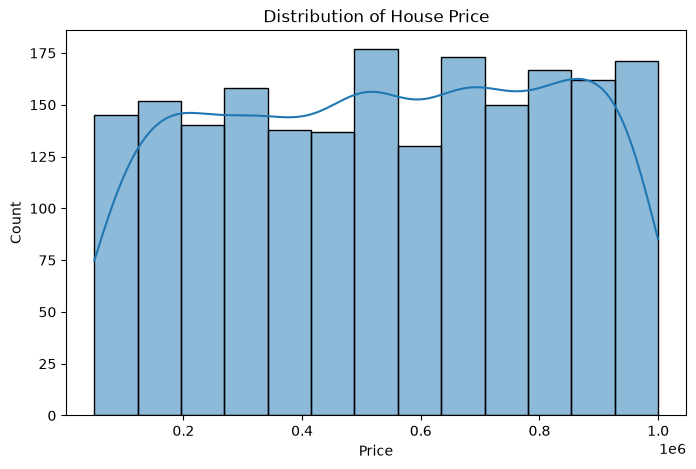

In [168]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Price"],
    kde=True
)

plt.title("Distribution of House Price")
plt.show()

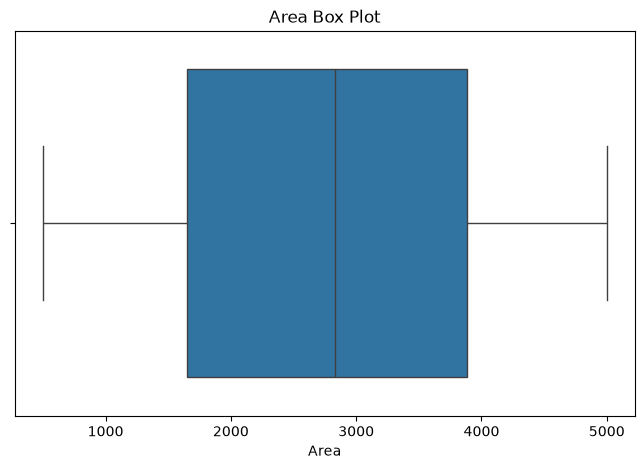

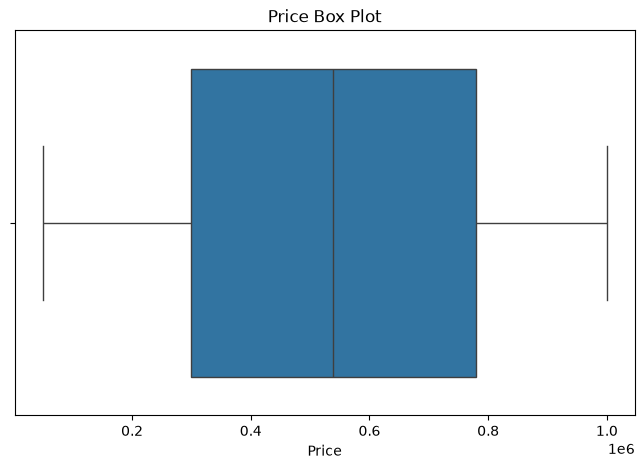

In [169]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["Area"]
)

plt.title("Area Box Plot")
plt.show()

plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["Price"]
)

plt.title("Price Box Plot")
plt.show()

In [171]:
X = df[["Area"]]

y = df["Price"]

print("\nInput Feature Shape :", X.shape)
print("Target Shape :", y.shape)

print("\nSelected Feature")
print(X.head())

print("\nTarget Variable")
print(y.head())


Input Feature Shape : (2000, 1)
Target Shape : (2000,)

Selected Feature
   Area
0  1360
1  4272
2  3592
3   966
4  4926

Target Variable
0    149919
1    424998
2    266746
3    244020
4    636056
Name: Price, dtype: int64


In [173]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [174]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

print("\nModel Training Completed Successfully!")


Model Training Completed Successfully!


In [175]:
print("\nIntercept (c)")
print(model.intercept_)

print("\nCoefficient (m)")
print(model.coef_)


Intercept (c)
536693.6793940249

Coefficient (m)
[-0.18386104]


In [176]:
train_predictions = model.predict(X_train)

In [177]:
test_predictions = model.predict(X_test)

In [179]:
prediction_df = X_test.copy()

prediction_df["Actual Price"] = y_test.values
prediction_df["Predicted Price"] = test_predictions

print("\nSample Predictions")

print(prediction_df.head(10))


Sample Predictions
      Area  Actual Price  Predicted Price
1860   633        514764    536577.295354
353   3856        694256    535984.711216
1333  1598         66375    536399.869449
905   1705        650243    536380.196317
1289  2564        223285    536222.259682
1273  3219        468127    536101.830700
938   2565        513002    536222.075821
1731  3131        911525    536118.010472
65    1775        723265    536367.326045
1323  4109        339416    535938.194373


In [180]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
print("\n========== Training Performance ==========")

train_mae = mean_absolute_error(y_train, train_predictions)

train_mse = mean_squared_error(y_train, train_predictions)

train_rmse = np.sqrt(train_mse)

train_r2 = r2_score(y_train, train_predictions)

print("Train MAE :", train_mae)
print("Train MSE :", train_mse)
print("Train RMSE:", train_rmse)
print("Train R2  :", train_r2)

# --------------------------
# Testing Metrics
# --------------------------

print("\n========== Testing Performance ==========")

test_mae = mean_absolute_error(y_test, test_predictions)

test_mse = mean_squared_error(y_test, test_predictions)

test_rmse = np.sqrt(test_mse)

test_r2 = r2_score(y_test, test_predictions)

print("Test MAE :", test_mae)
print("Test MSE :", test_mse)
print("Test RMSE:", test_rmse)
print("Test R2  :", test_r2)



========== Training Performance ==========
Train MAE : 238196.98665679814
Train MSE : 76007463480.74089
Train RMSE: 275694.5111545402
Train R2  : 7.52495507683193e-07

========== Testing Performance ==========
Test MAE : 242478.32249473498
Test MSE : 77856127383.1798
Test RMSE: 279027.1086887075
Test R2  : -0.0007365003351658128


In [181]:

from sklearn.model_selection import cross_val_score


cv_scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring="r2"
)

print("\n========== Cross Validation ==========")

print("Individual Scores")

print(cv_scores)

print("\nAverage Cross Validation Score")

print(cv_scores.mean())

# ============================================================
# Model Summary
# ============================================================

print("\n==============================")
print("Simple Linear Regression Summary")
print("==============================")

print(f"Intercept           : {model.intercept_:.2f}")

print(f"Coefficient         : {model.coef_[0]:.2f}")

print(f"Train R2 Score      : {train_r2:.4f}")

print(f"Test R2 Score       : {test_r2:.4f}")

print(f"Cross Validation R2 : {cv_scores.mean():.4f}")




========== Cross Validation ==========
Individual Scores
[-0.0034492  -0.00081826 -0.0053138  -0.00623327 -0.00523847]

Average Cross Validation Score
-0.004210602024905974

Simple Linear Regression Summary
Intercept           : 536693.68
Coefficient         : -0.18
Train R2 Score      : 0.0000
Test R2 Score       : -0.0007
Cross Validation R2 : -0.0042


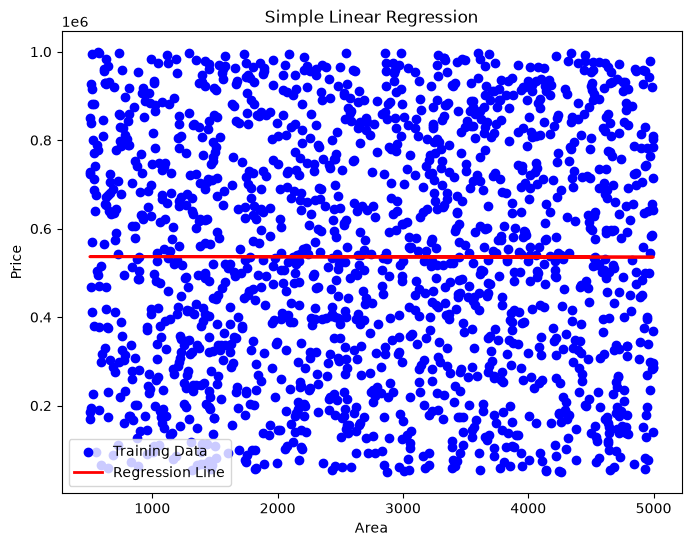

In [182]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_train,
    y_train,
    color="blue",
    label="Training Data"
)

# Plot the best-fit regression line
plt.plot(
    X_train,
    train_predictions,
    color="red",
    linewidth=2,
    label="Regression Line"
)

plt.title("Simple Linear Regression")
plt.xlabel("Area")
plt.ylabel("Price")
plt.legend()

plt.show()

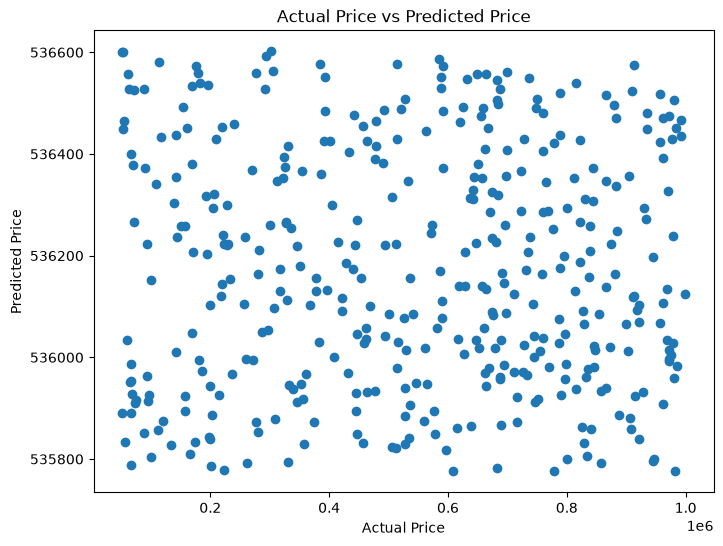

In [183]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    test_predictions
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual Price vs Predicted Price")

plt.show()


In [184]:
residuals = y_test - test_predictions

print("First 10 Residuals")

print(residuals.head(10))

First 10 Residuals
1860    -21813.295354
353     158271.288784
1333   -470024.869449
905     113862.803683
1289   -312937.259682
1273    -67974.830700
938     -23220.075821
1731    375406.989528
65      186897.673955
1323   -196522.194373
Name: Price, dtype: float64


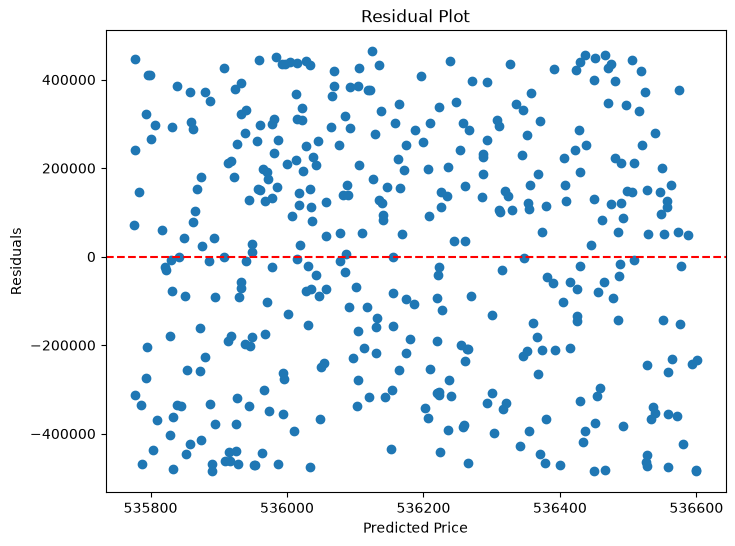

In [185]:
plt.figure(figsize=(8,6))

plt.scatter(
    test_predictions,
    residuals
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted Price")
plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

In [186]:
print("Residual Skewness")

print(residuals.skew())

Residual Skewness
-0.1657696892107013


In [188]:
new_house = pd.DataFrame({

    "Area":[2500]

})

predicted_price = model.predict(new_house)

print("\nPredicted House Price")

print(predicted_price)


Predicted House Price
[536234.02678914]


In [190]:
from joblib import dump


dump(model,"house_price_model.joblib")

print("\nModel Saved Successfully!")





Model Saved Successfully!


In [191]:
from joblib import load

loaded_model = load("house_price_model.joblib")

print("\nModel Loaded Successfully!")




Model Loaded Successfully!


In [192]:
prediction = loaded_model.predict(new_house)

print("\nPrediction Using Loaded Model")

print(prediction)




Prediction Using Loaded Model
[536234.02678914]


In [193]:
print("\n========================================")
print("Simple Linear Regression Project Summary")
print("========================================")

print(f"Feature Used              : Area")
print(f"Target                    : Price")

print(f"Training Samples          : {len(X_train)}")
print(f"Testing Samples           : {len(X_test)}")

print(f"Intercept                 : {model.intercept_:.2f}")
print(f"Coefficient               : {model.coef_[0]:.2f}")

print(f"Train R2 Score            : {train_r2:.4f}")
print(f"Test R2 Score             : {test_r2:.4f}")
print(f"Cross Validation Score    : {cv_scores.mean():.4f}")

print(f"Test MAE                  : {test_mae:.2f}")
print(f"Test RMSE                 : {test_rmse:.2f}")

print("\nModel Ready for Deployment!")

print("\nProject Completed Successfully!")


Simple Linear Regression Project Summary
Feature Used              : Area
Target                    : Price
Training Samples          : 1600
Testing Samples           : 400
Intercept                 : 536693.68
Coefficient               : -0.18
Train R2 Score            : 0.0000
Test R2 Score             : -0.0007
Cross Validation Score    : -0.0042
Test MAE                  : 242478.32
Test RMSE                 : 279027.11

Model Ready for Deployment!

Project Completed Successfully!
